# 01 · The State Model

**Purpose:** Predicts, for any account-trip at any price, the probability distribution across behavioral states — a probability that must be numerically right and move correctly with price, not just rank correctly, since the simulation multiplies it by revenue.

**Architecture:** Two stages, separated on purpose.

| Stage | Method | Handles |
|---|---|---|
| 1 | Gradient-boosted trees on non-price features | Customer heterogeneity — who this account is |
| 2 | Multinomial logit with stage 1 as a fixed offset | The price dimension only |

1. A single tree model on all features including price fails three ways
  - Cannot interpolate between the discrete price levels in the data
  - Its price response is whatever the trees happened to fit, not an identified effect
  - Produces local reversals where a higher price looks better for retention
2. A parametric price term with a pinned offset fixes all three

**What the plan requires:**

| Requirement | Why it cannot be skipped |
|---|---|
| Labels reconstructed from observables | The five states are unobserved in production |
| Split by time, never at random | A random split leaks the future into the past |
| Price identified, not just fitted | Price was not randomly assigned |
| Monotone, smooth price response | Simulation curves must be defensible and continuous |
| Calibrated probabilities | Σ P(state) × revenue(state) consumes quantities, not rankings |
| Response that transfers | Applying a new price to the whole book assumes it does |


In [1]:
# Load Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score
from IPython.display import display

DATA = Path('data/synthetic')


def load(name):
    pq, csv = DATA / f'{name}.parquet', DATA / f'{name}.csv'
    if pq.exists():
        return pd.read_parquet(pq)
    if csv.exists():
        return pd.read_csv(csv)
    raise FileNotFoundError(f'{name} not found in {DATA.resolve()} — run the data notebook first.')


accounts = load('accounts')
macro = load('macro')
trips = load('trips').merge(accounts, on='account_id', how='left')
trips = trips.merge(macro[['month', 'macro_index']], on='month', how='left')
ground_truth = load('ground_truth')     # §9 only, never a feature

CLASSES = ['no_purchase', 'reduces', 'unchanged', 'increases']
IDX = {c: i for i, c in enumerate(CLASSES)}

# log_loss column-order guard: keeps class order consistent regardless of sklearn's own sorting
SORTED = sorted(CLASSES)
PERM = [CLASSES.index(c) for c in SORTED]


def LL(yv, P):
    return log_loss(yv, P[:, PERM], labels=SORTED)


def softmax(eta):
    e = np.exp(eta - eta.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)


SURFACE = '#ffffff'
INK = '#0b0b0b'
MUTED = '#898781'
GRID = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'
ACCENT2 = '#eb6834'
RED = '#e34948'

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})

print(f'{len(trips):,} trips · {trips.account_id.nunique():,} accounts · {trips.month.nunique()} months')


94,579 trips · 29,406 accounts · 24 months


---
## 1 · Reconstruct the Labels

**Purpose:** Reconstructs the five behavioral states from observable data alone, using the labeling rule the data notebook selected, since production never records the true state.

**Design Notes:**

1. Rule: coverage ratio below 0.70 counts as a reduction
  - Won on F1 among 19 candidates tested in the data notebook
  - Higher recall than the runner-up: under-labelling a real reduction is the more expensive error here
2. substitutes and leaves pooled as no_purchase
  - Indistinguishable at trip level; both look like zero purchase
  - Split apart again at account level in §10

**Observations:**

1. Reconstructed labels: unchanged 72.7%, reduces 11.3%, no_purchase 9.5%, increases 6.5%
2. Matches the true (pooled) state 95.1% of the time
3. Base-rate log loss of 0.8792 sets the bar any model must beat


In [2]:
# Reconstruct Labels
DAY_THRESH = 0.70


def reconstruct_label(df, day_thresh=DAY_THRESH):
    ratio = df['days_bought'] / df['days_traveled']
    lines = df['lines_active'] / df['lines_traveling'].clip(lower=1)
    y = pd.Series('unchanged', index=df.index, dtype=object)
    y[ratio > 1.0] = 'increases'
    y[(ratio < day_thresh) | (lines < 0.999)] = 'reduces'
    y[df['days_bought'] == 0] = 'no_purchase'
    return y


trips['y'] = reconstruct_label(trips)
truth_pooled = trips['state'].replace({'substitutes': 'no_purchase', 'leaves': 'no_purchase'})
y = trips['y'].to_numpy()
yi = np.array([IDX[v] for v in y])

display(trips['y'].value_counts(normalize=True).round(4).to_frame('share of trips').rename_axis(None))

print(f'Agreement with the true state: {(trips.y == truth_pooled).mean():.1%}')

base = trips['y'].value_counts(normalize=True).reindex(CLASSES).to_numpy()
BASE_LL = -(base * np.log(base)).sum()
print(f'Benchmark — log loss of a constant base-rate predictor: {BASE_LL:.4f}')
print('Any model above this is actively harmful, whatever its other metrics say.')


,share of trips
unchanged,0.7270
reduces,0.1134
no_purchase,0.0949
increases,0.0647


Agreement with the true state: 95.1%
Benchmark — log loss of a constant base-rate predictor: 0.8792
Any model above this is actively harmful, whatever its other metrics say.


---
## 2 · Features, and Two Audits

**Purpose:** Builds the non-price feature matrix for stage 1, after auditing it for leakage and collinearity.

**Design Notes:**

1. Leakage audit: features must be knowable before the purchase decision
  - days_bought, lines_active: these define the label itself
  - pass_revenue, account_lost: downstream of the decision
  - state: the true label
  - price_sensitivity, travel_propensity: latent truth, unobservable in production
2. Collinearity audit: substitute_ease is a deterministic lookup from region
  - Interacting it with price would split the price effect arbitrarily between two collinear terms, potentially inverting the sign of one
  - substitute_ease is excluded from both stages; region dummies in stage 1 already carry the same information, and it is never a stage-2 price interaction
3. prior_trips uses an expanding window: only trips in earlier months count, so no future leaks into a feature

**Observations:**

1. substitute_ease confirmed deterministic: exactly one value per region
2. 17 non-price features survive the audits


In [3]:
# Collinearity Audit
ease_by_region = trips.groupby('region')['substitute_ease'].nunique()
print('Distinct substitute_ease values per region')
display(ease_by_region.to_frame('distinct values').rename_axis(None))
DETERMINISTIC = bool((ease_by_region == 1).all())
print(f'substitute_ease is a deterministic function of region: {DETERMINISTIC}')


def build_features(df):
    out = pd.DataFrame(index=df.index)
    out['is_business'] = df['is_business'].astype(int)
    out['lines_on_account'] = df['lines_on_account']
    out['tenure_months'] = df['tenure_months']
    out['premium'] = (df['plan_tier'] == 'premium').astype(int)
    out['value_tier'] = (df['plan_tier'] == 'value').astype(int)
    out['lines_traveling'] = df['lines_traveling']
    out['days_traveled'] = df['days_traveled']
    for r in ['asia', 'caribbean', 'central_america', 'europe', 'mideast', 'oceania', 'south_america']:  # africa omitted as reference
        out[f'region_{r}'] = (df['region'] == r).astype(int)
    out['month_of_year'] = df['month'] % 12
    out['macro_index'] = df['macro_index']
    return out


hist = trips[['account_id', 'month']].sort_values(['account_id', 'month'])
cum = hist.groupby('account_id').cumcount()
same = hist.groupby(['account_id', 'month']).cumcount()
trips['prior_trips'] = (cum - same).reindex(trips.index).fillna(0).astype(int)
trips['log_price'] = np.log(trips['price_multiplier'])

X = build_features(trips)
X['prior_trips'] = trips['prior_trips']

LEAKY = {'days_bought', 'lines_active', 'pass_revenue', 'account_lost', 'state',
         'price_sensitivity', 'travel_propensity', 'price_multiplier', 'log_price'}
assert not (set(X.columns) & LEAKY), 'leakage in the stage-1 feature matrix'
print(f'Stage 1: {X.shape[1]} non-price features')


Distinct substitute_ease values per region


,distinct values
africa,1
asia,1
caribbean,1
central_america,1
europe,1
mideast,1
oceania,1
south_america,1


substitute_ease is a deterministic function of region: True
Stage 1: 17 non-price features


---
## 3 · Split by Time

**Purpose:** Splits trips by time, not at random, so the price response can be validated on data the model never trained on.

**Design Notes:**

1. Three slices by month

| Slice | Months | Purpose |
|---|---|---|
| train | 0-15 | fit both stages |
| calib | 16-19 | fit the probability calibrator |
| test | 20-23 | report everything |

2. A structural limitation, not a fixable boundary: the market price test ran in months 8-15, so any late window carries only small random drift
  - The temporal test set validates general accuracy well, but the price response only weakly
  - §6.2 adds a regional holdout instead, the check that actually matters for a simulation re-pricing the whole book

**Observations:**

1. Train (months 0-15): 54,045 trips, 22,624 accounts, 38.7% off-standard, 5 price levels
2. Calib (months 16-19): 22,062 trips, 13,298 accounts, 38.8% off-standard, 4 price levels
3. Test (months 20-23): 18,472 trips, 11,799 accounts, only 10.1% off-standard, 3 price levels — confirming the limitation above


In [4]:
# Split by Time
month = trips['month'].to_numpy()
tr, ca, te = month <= 15, (month >= 16) & (month <= 19), month >= 20

display(pd.DataFrame({
    'trips': [s.sum() for s in (tr, ca, te)],
    'accounts': [trips.account_id[s].nunique() for s in (tr, ca, te)],
    'off-standard %': [round((trips.price_multiplier[s] != 1.0).mean(), 3) for s in (tr, ca, te)],
    'price levels': [trips.price_multiplier[s].nunique() for s in (tr, ca, te)],
}, index=['train (0-15)', 'calib (16-19)', 'test (20-23)']))


,trips,accounts,off-standard %,price levels
train (0-15),54045,22624,0.387,5
calib (16-19),22062,13298,0.388,4
test (20-23),18472,11799,0.101,3


---
## 4 · Identification: Is the Price Coefficient Real?

**Purpose:** Establishes whether the price coefficient is real, separate from predictive accuracy — the question a pricing analysis lives or dies on.

**Design Notes:**

1. Price moved three ways during the historical window
  - A market test in Europe and Asia-Pacific (Asia + Oceania), months 8-15
  - A promotional window
  - A little random drift — only this is clean
2. Three specs test how much of the naive estimate is confounding

| Spec | Controls | Identifies off |
|---|---|---|
| naive | none | everything correlated with price |
| controlled | region + month | residual within-region, within-month variation |
| saturated | region × month | drift only — clean, but much less of it |

3. These estimates are the benchmark for stage 2: its coefficients should land near the controlled column; if they don't, stage 2 is picking up something other than the price effect

**Observations:**

1. Naive effect overstates the response for every class (e.g. no_purchase 3.09 vs. 1.74 controlled), confirming meaningful confounding
2. Confounding is modest for reduces/increases (7-9% of the naive effect) but substantial for no_purchase/unchanged (40-54%)
3. Controlled and saturated specs broadly agree, confirming the controlled estimate is a stable benchmark for stage 2


In [5]:
# Identify Price Effect
def logit_price_effect(spec):
    cols = ['is_business', 'lines_on_account', 'tenure_months', 'premium', 'value_tier',
            'lines_traveling', 'days_traveled', 'prior_trips']
    D = X.loc[tr, cols].copy()
    D['log_price'] = trips.loc[tr, 'log_price']
    if spec in ('controlled', 'saturated'):
        D = pd.concat([D, pd.get_dummies(trips.loc[tr, 'region'], prefix='reg', drop_first=True),
                       pd.get_dummies(trips.loc[tr, 'month'], prefix='m', drop_first=True)], axis=1)
    if spec == 'saturated':
        rm = trips.loc[tr, 'region'].astype(str) + '_' + trips.loc[tr, 'month'].astype(str)
        D = pd.concat([D, pd.get_dummies(rm, prefix='rm', drop_first=True)], axis=1)

    D = D.astype(float)
    sc = StandardScaler().fit(D)
    m = LogisticRegression(max_iter=3000, C=1.0).fit(sc.transform(D), y[tr])
    j = list(D.columns).index('log_price')
    return pd.Series(m.coef_[:, j] / sc.scale_[j], index=m.classes_), D.shape[1]


ident = {}
for spec in ['naive', 'controlled', 'saturated']:
    eff, k = logit_price_effect(spec)
    ident[f'{spec} (k={k})'] = eff
ident = pd.DataFrame(ident).reindex(CLASSES).round(3)
print('Effect of log(price) on each state')
display(ident)

# Relative to the reference class — the form stage 2 will estimate
rel = ident.sub(ident.loc['unchanged'], axis=1).round(3)
print("Same effects relative to 'unchanged' (the stage-2 reference)")
display(rel)
# controlled is always column 2 by construction; index positionally, not by name
TARGET = rel.iloc[:, 1]

conf = ((ident.iloc[:, 0] - ident.iloc[:, 1]).abs() / ident.iloc[:, 0].abs()).round(3)
print('Share of the naive effect attributable to confounding')
display(conf.to_frame('share').rename_axis(None))


Effect of log(price) on each state


,naive (k=9),controlled (k=31),saturated (k=158)
no_purchase,2.244,1.350,1.243
reduces,1.983,2.123,2.279
unchanged,-0.841,-0.390,-0.612
increases,-3.386,-3.083,-2.909


Same effects relative to 'unchanged' (the stage-2 reference)


,naive (k=9),controlled (k=31),saturated (k=158)
no_purchase,3.085,1.740,1.855
reduces,2.824,2.513,2.891
unchanged,0.000,0.000,0.000
increases,-2.545,-2.693,-2.297


Share of the naive effect attributable to confounding


,share
no_purchase,0.398
reduces,0.071
unchanged,0.536
increases,0.089


---
## 5 · Stage 1 — Heterogeneity, No Price

**Purpose:** Fits one non-price model to capture customer heterogeneity — who this account is and what kind of trip this is — before price enters at stage 2.

**Design Notes:**

1. Multiclass gradient-boosted trees on non-price features only
2. Fitted on standard-price trips only
  - Stage 1 carries region and month; the market test ran region × month, so a stage 1 fitted on everything would learn the price effect through those two features and leave stage 2 with almost nothing to estimate
  - Costs about a third of the training rows, but keeps the separation between customer heterogeneity and price genuine
3. AUC per class is the honest diagnostic, not argmax accuracy
  - With 76% of trips unchanged, argmax will predict unchanged almost everywhere — a well-calibrated weak model doing its job, not a failure
  - increases should show AUC near 0.5: its signal is entirely in price, which stage 1 cannot see

**Observations:**

1. Stage 1 trains on 33,127 standard-price trips (61% of train)
2. Test log loss 0.8667, barely above the base-rate benchmark (0.8792) — expected, since stage 1 alone carries no price signal
3. Per-class AUC: no_purchase 0.589, reduces 0.596, unchanged 0.565, increases 0.504 — increases lands at ~0.5 exactly as predicted
4. Aggregate calibration tracks observed shares closely across all four classes


In [6]:
# Fit Stage 1
S1_TRAIN = tr & (trips['price_multiplier'] == 1.0).to_numpy()
print(f'stage 1 trains on {S1_TRAIN.sum():,} standard-price trips '
      f'({S1_TRAIN.sum() / tr.sum():.0%} of train)\n')

gbm = HistGradientBoostingClassifier(
    max_iter=400, learning_rate=0.06, max_leaf_nodes=31, min_samples_leaf=40,
    l2_regularization=1.0, early_stopping=True, validation_fraction=0.15, random_state=0,
).fit(X[S1_TRAIN], y[S1_TRAIN])
ORDER = [list(gbm.classes_).index(c) for c in CLASSES]


def stage1_proba(Xf):
    P = gbm.predict_proba(Xf)[:, ORDER]
    P = np.clip(P, 1e-6, None)
    return P / P.sum(axis=1, keepdims=True)


P0_te = stage1_proba(X[te])
print(f'stage 1 log loss (test) : {LL(y[te], P0_te):.4f}')
print(f'base-rate benchmark     : {BASE_LL:.4f}')

print('Per-class AUC — the diagnostic a constant predictor cannot fake')
auc_tbl = pd.Series({c: roc_auc_score((y[te] == c).astype(int), P0_te[:, i])
                     for i, c in enumerate(CLASSES)}, name='AUC').round(3)
display(auc_tbl.to_frame())
print('(increases near 0.500 is expected: its signal is price, which stage 1 lacks)')

print('Aggregate calibration of stage 1')
display(pd.DataFrame({'predicted': P0_te.mean(0),
                      'observed': [(y[te] == c).mean() for c in CLASSES]},
                     index=CLASSES).round(4))


stage 1 trains on 33,127 standard-price trips (61% of train)



stage 1 log loss (test) : 0.8667
base-rate benchmark     : 0.8792
Per-class AUC — the diagnostic a constant predictor cannot fake


,AUC
no_purchase,0.589
reduces,0.596
unchanged,0.565
increases,0.504


(increases near 0.500 is expected: its signal is price, which stage 1 lacks)
Aggregate calibration of stage 1


,predicted,observed
no_purchase,0.0873,0.0941
reduces,0.1165,0.1091
unchanged,0.7210,0.7301
increases,0.0751,0.0667


---
## 6 · Stage 2 — the Price Dimension, as a True Offset

**Purpose:** Fits the price dimension as a true offset on top of stage 1, so only the price parameters are estimated and stage 1's calibration is inherited rather than rescaled.

**Design Notes:**

1. Stage 1's log-probabilities enter with coefficient pinned at 1 — that's what "offset" means
  - Passing them as an ordinary feature instead would let the model rescale them freely, distorting the calibration stage 1 already achieved
2. Nine parameters, unchanged as reference:

$$\eta_c = \log P^{(1)}_c + \beta_c \cdot \ell + \gamma_c \cdot \ell \cdot \text{business} + \delta_c \cdot \ell \cdot (\text{party}-1), \quad \ell = \log(\text{price multiplier})$$

  - Interactions: business and party size only; substitute_ease excluded per §2's collinearity finding
3. Sign constraints enforced on the net row-level effect, not just the base coefficient
  - Checking only the base coefficient can pass while the net effect (base + interactions) is inverted for most of the book

**Observations:**

1. Converged; ratio to §4's identified estimate: no_purchase 1.08x, reduces 0.80x, increases 0.57x
2. increases falls outside the healthy [0.6, 1.6] range — stage 1 is still absorbing part of that class's response
3. Every row carries the correct sign (0.00% wrong-signed); interactions retained
4. Hybrid log loss (0.8660) barely improves on stage 1 alone (0.8667) — expected, since price affects a minority of trips


In [7]:
# Fit Stage 2
FIT_CLASSES = ['no_purchase', 'reduces', 'increases']      # unchanged = reference
TERMS = ['log_price', 'lp_x_business', 'lp_x_party']
SIGN = {'no_purchase': +1, 'reduces': +1, 'increases': -1}


def price_design(df, mult=None):
    lp = np.log(float(mult)) * np.ones(len(df)) if mult is not None \
        else df['log_price'].to_numpy()
    return np.column_stack([
        lp,
        lp * df['is_business'].to_numpy().astype(float),
        lp * (df['lines_traveling'].to_numpy() - 1.0),
    ])


def nll(theta, logP0, Z, yidx, l2=1e-4):
    B = theta.reshape(len(FIT_CLASSES), Z.shape[1])
    eta = logP0.copy()
    for k, c in enumerate(FIT_CLASSES):
        eta[:, IDX[c]] += Z @ B[k]
    m = eta.max(axis=1, keepdims=True)
    lse = m[:, 0] + np.log(np.exp(eta - m).sum(axis=1))
    return -(eta[np.arange(len(yidx)), yidx] - lse).mean() + l2 * (theta ** 2).sum()


logP0_tr = np.log(stage1_proba(X[tr]))
Z_tr = price_design(trips[tr])

bounds = []
for c in FIT_CLASSES:
    bounds += [(0, 12)] if SIGN[c] > 0 else [(-12, 0)]      # base term, sign-bounded
    bounds += [(-3, 3), (-1, 1)]                              # interactions

res = minimize(nll, np.zeros(len(FIT_CLASSES) * len(TERMS)),
               args=(logP0_tr, Z_tr, yi[tr]), method='L-BFGS-B',
               bounds=bounds, options={'maxiter': 500})
B = res.x.reshape(len(FIT_CLASSES), len(TERMS))

coefs = pd.DataFrame(B, index=FIT_CLASSES, columns=TERMS).round(3)
print(f'converged: {res.success}   NLL: {res.fun:.4f}')
print("Stage-2 price coefficients (relative to 'unchanged')")
display(coefs)

print("Benchmark against §4's identified estimates")
check = pd.DataFrame({'stage 2 base': coefs['log_price'],
                      '§4 controlled (rel.)': TARGET.reindex(FIT_CLASSES)}).round(3)
display(check)
ratio = (check['stage 2 base'] / check['§4 controlled (rel.)']).abs()
print(f'\nratio to the identified estimate: ' +
      '  '.join(f'{c}={v:.2f}' for c, v in ratio.items()))
if ((ratio < 0.6) | (ratio > 1.6)).any():
    print('\nWARNING: stage 2 is not recovering the identified price effect. If the')
    print('ratios are well below 1, stage 1 is still absorbing part of the response.')
else:
    print('\nStage 2 recovers the identified effect. The separation is working.')

# --- net effect per row, the sign check that actually matters ---
biz = trips['is_business'].to_numpy().astype(float)
party = trips['lines_traveling'].to_numpy() - 1.0
net = {c: B[k, 0] + B[k, 1] * biz + B[k, 2] * party for k, c in enumerate(FIT_CLASSES)}

print('Net log-price effect per trip — min / median / max, and wrong-signed share')
net_tbl = pd.DataFrame({
    c: {'min': net[c].min(), 'median': np.median(net[c]), 'max': net[c].max(),
        'wrong sign': (net[c] * SIGN[c] < 0).mean()}
    for c in FIT_CLASSES
}).T.round(4)
display(net_tbl)

WORST = max((net[c] * SIGN[c] < 0).mean() for c in FIT_CLASSES)
if WORST > 0.01:
    print(f'\n{WORST:.1%} of rows carry a wrong-signed net effect. Refitting without')
    print('interactions so the sign is guaranteed everywhere.')
    b2 = []
    for c in FIT_CLASSES:
        b2 += [(0, 12)] if SIGN[c] > 0 else [(-12, 0)]
        b2 += [(0, 0), (0, 0)]
    res = minimize(nll, np.zeros(9), args=(logP0_tr, Z_tr, yi[tr]),
                   method='L-BFGS-B', bounds=b2, options={'maxiter': 500})
    B = res.x.reshape(len(FIT_CLASSES), len(TERMS))
    print(pd.DataFrame(B, index=FIT_CLASSES, columns=TERMS).round(3).to_string())
else:
    print('\nAll rows carry the correct sign. Interactions retained.')


def raw_score(Xf, df, mult=None):
    eta = np.log(stage1_proba(Xf))
    Z = price_design(df, mult)
    for k, c in enumerate(FIT_CLASSES):
        eta[:, IDX[c]] += Z @ B[k]
    return softmax(eta)


P_te = raw_score(X[te], trips[te])
print(f'\nhybrid log loss (test) : {LL(y[te], P_te):.4f}')
print(f'stage 1 alone          : {LL(y[te], P0_te):.4f}')
print(f'base-rate benchmark    : {BASE_LL:.4f}')


converged: True   NLL: 0.8573
Stage-2 price coefficients (relative to 'unchanged')


,log_price,lp_x_business,lp_x_party
no_purchase,1.881,-0.343,0.165
reduces,2.021,-0.136,0.056
increases,-1.541,-0.281,-0.220


Benchmark against §4's identified estimates


,stage 2 base,§4 controlled (rel.)
no_purchase,1.881,1.740
reduces,2.021,2.513
increases,-1.541,-2.693



ratio to the identified estimate: no_purchase=1.08  reduces=0.80  increases=0.57

ratios are well below 1, stage 1 is still absorbing part of the response.
Net log-price effect per trip — min / median / max, and wrong-signed share


,min,median,max,wrong sign
no_purchase,1.5388,1.7041,2.5423,0.0
reduces,1.8848,1.9406,2.2441,0.0
increases,-2.7011,-1.8218,-1.5408,0.0



All rows carry the correct sign. Interactions retained.

hybrid log loss (test) : 0.8660
stage 1 alone          : 0.8667
base-rate benchmark    : 0.8792


### 6.1 The Price Sweep

**Purpose:** Re-scores the whole test set across the full price range, exactly as the simulation will, to confirm the response is smooth, monotone, and segment-differentiated.

**Design Notes:**

1. Score every price from -10% to +20% — a defect here is a defect in the simulation
2. Three checks
  - No reversals
  - No flat plateaus between observed price levels
  - The substantive one: business and consumer must respond differently, since that's the entire basis of a selective price increase
3. Chart: consistent color per state (loss states in red/orange, neutral in gray, gain in blue), matching the data notebook's convention

**Observations:**

1. Zero monotonicity violations and zero flat steps across all four states
2. Consumer P(no purchase) swings +5.72 points across the range vs. business +2.62 points — consumer responds more, as required
3. Matches the raw, unmodelled no-purchase pattern by segment and price


,no_purchase,reduces,unchanged,increases
0.90,0.0740,0.0972,0.7362,0.0926
0.95,0.0807,0.1068,0.7293,0.0833
1.00,0.0873,0.1165,0.7210,0.0751
1.05,0.0940,0.1262,0.7118,0.0680
1.10,0.1006,0.1360,0.7017,0.0617
1.15,0.1071,0.1458,0.6910,0.0561
1.20,0.1136,0.1555,0.6798,0.0511



Monotonicity violations : {'no_purchase': 0, 'reduces': 0, 'unchanged': 0, 'increases': 0}
Flat steps (staircase)  : {'no_purchase': 0, 'reduces': 0, 'unchanged': 0, 'increases': 0}


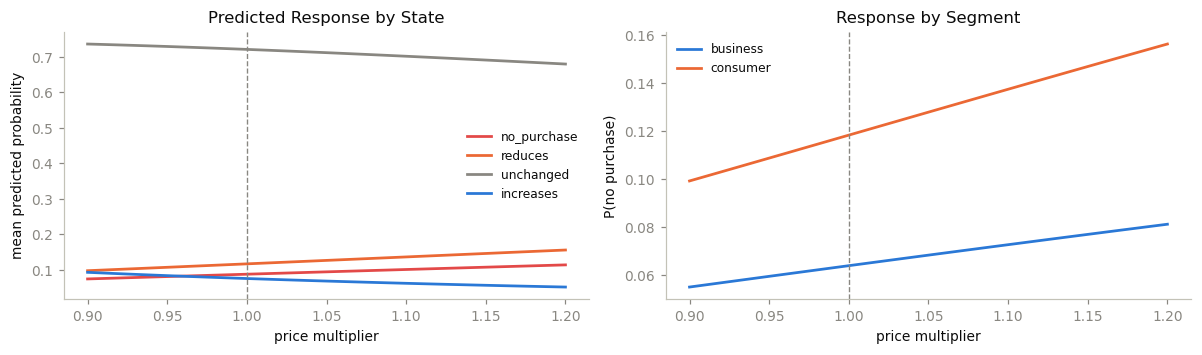

P(no purchase) swing across the range — business +0.0262, consumer +0.0572
Consumer should swing wider. If it does not, the selective-increase premise fails.
Observed no-purchase rate by segment and price (all trips)


,0.90,0.95,1.00,1.10,1.20
consumer,0.103,0.111,0.118,0.163,0.214
business,0.068,0.066,0.067,0.082,0.090


In [8]:
# Sweep Price Range
GRID = np.round(np.linspace(0.90, 1.20, 25), 4)  # 25 points, 1.25pp apart, endpoints included exactly
SWEEP_SIGN = {'no_purchase': +1, 'reduces': +1, 'unchanged': -1, 'increases': -1}

sweep = pd.DataFrame(
    [dict(zip(CLASSES, raw_score(X[te], trips[te], m).mean(axis=0)), price_multiplier=m)
     for m in GRID]).set_index('price_multiplier')
display(sweep.iloc[::4].round(4).rename_axis(None))

viol = {c: int(((sweep[c].diff().dropna()) * SWEEP_SIGN[c] < -1e-9).sum()) for c in CLASSES}
flat = {c: int((sweep[c].diff().abs().dropna() < 1e-9).sum()) for c in CLASSES}
print(f'\nMonotonicity violations : {viol}')
print(f'Flat steps (staircase)  : {flat}')

i_np = IDX['no_purchase']
fig, axes = plt.subplots(1, 2, figsize=(11, 3.3))
for c, col in zip(CLASSES, [RED, ACCENT2, MUTED, ACCENT]):
    axes[0].plot(sweep.index, sweep[c], label=c, color=col, linewidth=1.8)
axes[0].axvline(1.0, color=MUTED, linestyle='--', linewidth=0.9)
axes[0].set_xlabel('price multiplier')
axes[0].set_ylabel('mean predicted probability')
axes[0].set_title('Predicted Response by State')
axes[0].legend(frameon=False, fontsize=8)

spans = {}
for seg, lbl, col in [(1, 'business', ACCENT), (0, 'consumer', ACCENT2)]:
    m = trips[te]['is_business'].to_numpy().astype(int) == seg
    curve = [raw_score(X[te][m], trips[te][m], p)[:, i_np].mean() for p in GRID]
    spans[lbl] = curve[-1] - curve[0]
    axes[1].plot(GRID, curve, color=col, linewidth=1.8, label=lbl)
axes[1].axvline(1.0, color=MUTED, linestyle='--', linewidth=0.9)
axes[1].set_xlabel('price multiplier')
axes[1].set_ylabel('P(no purchase)')
axes[1].set_title('Response by Segment')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print(f"P(no purchase) swing across the range — business {spans['business']:+.4f}, "
      f"consumer {spans['consumer']:+.4f}")
print('Consumer should swing wider. If it does not, the selective-increase premise fails.')

# The raw data's own answer, for comparison
raw_cmp = (trips.assign(np_flag=(trips.y == 'no_purchase').astype(float))
           .pivot_table(index='is_business', columns='price_multiplier', values='np_flag'))
raw_cmp.index = raw_cmp.index.map({False: 'consumer', True: 'business'})
print('Observed no-purchase rate by segment and price (all trips)')
display(raw_cmp.round(3).rename_axis(None).rename_axis(None, axis=1))


### 6.2 Regional Price Holdout — the Gate

**Purpose:** Tests whether a price effect estimated on part of the book applies to the rest of it — the assumption the whole simulation is built on.

**Design Notes:**

1. The temporal split can't validate the price response, so hold out a region instead
  - Refit both stages with all Asia-Pacific trips removed
  - Predict Asia-Pacific trips during the market test, at elevated prices the model never saw for that region
2. If the model under-predicts the response, the revenue case is optimistic
  - It understates the damage from a price rise and makes the +20% ceiling look safer than it is
  - The ratio computed below is exported so notebook 03 can bracket the simulation rather than pretend the miss isn't there

**Observations:**

1. Predicted vs. observed no-purchase rate diverges at both held-out price levels (e.g. 1.20x: 9.83% predicted vs. 12.65% observed)
2. Response slope: observed / predicted = 1.49x — the model under-states the out-of-region response
3. Notebook 03 is directed to run the simulation scaled by 1.0 and by 1.49 to bracket the answer


In [9]:
# Regional Holdout
is_asia_pacific = trips['region'].isin(['asia', 'oceania']).to_numpy()
h_tr = tr & ~is_asia_pacific
h_s1 = h_tr & (trips['price_multiplier'] == 1.0).to_numpy()
h_te = is_asia_pacific & trips['month'].between(8, 15).to_numpy()

g_h = HistGradientBoostingClassifier(max_iter=400, learning_rate=0.06, max_leaf_nodes=31,
                                     min_samples_leaf=40, l2_regularization=1.0,
                                     early_stopping=True, validation_fraction=0.15,
                                     random_state=0).fit(X[h_s1], y[h_s1])
ord_h = [list(g_h.classes_).index(c) for c in CLASSES]


def s1_h(Xf):
    P = np.clip(g_h.predict_proba(Xf)[:, ord_h], 1e-6, None)
    return P / P.sum(axis=1, keepdims=True)


res_h = minimize(nll, np.zeros(9),
                 args=(np.log(s1_h(X[h_tr])), price_design(trips[h_tr]), yi[h_tr]),
                 method='L-BFGS-B', bounds=bounds, options={'maxiter': 500})
B_h = res_h.x.reshape(len(FIT_CLASSES), len(TERMS))

eta_h = np.log(s1_h(X[h_te]))
Z_h = price_design(trips[h_te])
for k, c in enumerate(FIT_CLASSES):
    eta_h[:, IDX[c]] += Z_h @ B_h[k]
P_h = softmax(eta_h)

cmp = (pd.DataFrame({'price': trips.loc[h_te, 'price_multiplier'].to_numpy(),
                     'predicted': P_h[:, i_np],
                     'observed': (y[h_te] == 'no_purchase').astype(float)})
       .groupby('price').agg(trips=('observed', 'size'),
                             predicted=('predicted', 'mean'),
                             observed=('observed', 'mean')).round(4))
cmp['error'] = (cmp['predicted'] - cmp['observed']).round(4)
print('Asia-Pacific during the market test, predicted by a model that never saw Asia-Pacific')
display(cmp.rename_axis(None))

if len(cmp) >= 2:
    pred_slope = cmp['predicted'].iloc[-1] - cmp['predicted'].iloc[0]
    obs_slope = cmp['observed'].iloc[-1] - cmp['observed'].iloc[0]
    RESPONSE_RATIO = float(obs_slope / pred_slope) if abs(pred_slope) > 1e-9 else np.nan
    print(f'\nResponse slope across the held-out price levels')
    print(f'  predicted {pred_slope:+.4f}   observed {obs_slope:+.4f}')
    print(f'  observed / predicted = {RESPONSE_RATIO:.2f}x')
    if RESPONSE_RATIO > 1.25:
        print('\n  The model UNDER-states the price response out of region. The revenue')
        print('  case built on it is optimistic. Notebook 03 must run the price response')
        print(f'  scaled by 1.0 and by {RESPONSE_RATIO:.2f} to bracket the answer.')
    elif RESPONSE_RATIO < 0.8:
        print('\n  The model OVER-states the response out of region; the case is')
        print('  conservative. Bracket it the same way.')
    else:
        print('\n  The response transfers. Applying one price to the whole book is justified.')
else:
    RESPONSE_RATIO = np.nan
    print('\nToo few held-out price levels to estimate a slope.')
    

Asia-Pacific during the market test, predicted by a model that never saw Asia-Pacific


,trips,predicted,observed,error
1.1,2687,0.0878,0.1109,-0.0231
1.2,2759,0.0983,0.1265,-0.0282



Response slope across the held-out price levels
  predicted +0.0105   observed +0.0156
  observed / predicted = 1.49x

  The model UNDER-states the price response out of region. The revenue
  case built on it is optimistic. Notebook 03 must run the price response
  scaled by 1.0 and by 1.49 to bracket the answer.


---
## 7 · Calibration

**Purpose:** Corrects the raw probabilities so they're numerically right, not just well-ranked, since the simulation consumes them as quantities.

**Design Notes:**

1. Isotonic regression, fit per class on the calib window (months 16-19)
2. The decision to calibrate at all is made without touching test
  - 70% of calib fits a decision-only isotonic; the remaining 30% scores raw vs. isotonic to decide (§8)
  - The production calibrator is then refit on the full calib window
  - Test (20-23) is reserved purely for reporting, never for that decision

**Observations:**

1. Isotonic improves Brier score for 3 of 4 classes on the held-out decision slice
2. On test, isotonic brings mean predicted rates much closer to observed (e.g. unchanged 0.7205 raw vs. 0.7303 isotonic vs. 0.7301 observed)
3. Brier improvements on test are small but consistent with the decision-slice result, confirming the choice generalizes


Calibration decision — held-out 30% of the calib window (not test)


,raw,isotonic
no_purchase,0.08154,0.08154
reduces,0.08937,0.08929
unchanged,0.18925,0.18882
increases,0.06283,0.06259


Brier score by class on TEST — reporting only, not used for the USE_CAL decision above


,raw,isotonic
no_purchase,0.08454,0.08451
reduces,0.09606,0.09633
unchanged,0.19533,0.19527
increases,0.06257,0.06231


Mean predicted vs observed rate


,observed,raw,isotonic
no_purchase,0.0941,0.0876,0.0924
reduces,0.1091,0.1170,0.1099
unchanged,0.7301,0.7205,0.7303
increases,0.0667,0.0749,0.0673


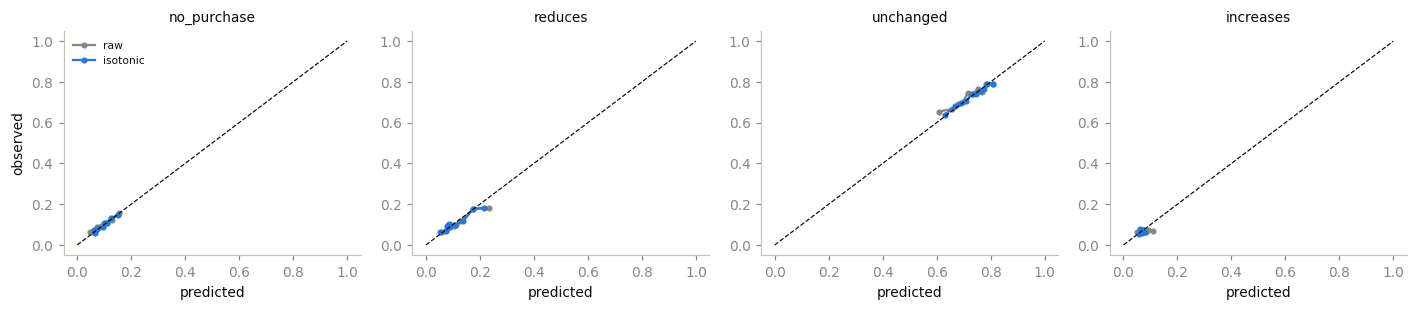

Caution: isotonic is fitted at observed prices. Applying it to a counterfactual
price assumes the correction does not itself depend on price — defensible over a
30-point range, and §6.2 is the check on the underlying response.


In [10]:
# Calibrate Probabilities
def brier_by_class(P, yv):
    return pd.Series({c: brier_score_loss((yv == c).astype(int), P[:, i])
                      for i, c in enumerate(CLASSES)})


def _calibrate_with(cals, P):
    Q = np.clip(np.column_stack([cals[c].predict(P[:, i]) for i, c in enumerate(CLASSES)]),
                1e-6, 1 - 1e-6)
    return Q / Q.sum(axis=1, keepdims=True)


# Decide WHETHER to calibrate on a held-out slice of calib, never on test
calib_rng = np.random.default_rng(0)
ca_pos = np.where(ca)[0]
perm = calib_rng.permutation(len(ca_pos))
n_fit = int(0.7 * len(ca_pos))
ca_fit, ca_eval = np.zeros_like(ca), np.zeros_like(ca)
ca_fit[ca_pos[perm[:n_fit]]] = True
ca_eval[ca_pos[perm[n_fit:]]] = True

CALS_decision = {c: IsotonicRegression(out_of_bounds='clip').fit(
                     raw_score(X[ca_fit], trips[ca_fit])[:, i], (y[ca_fit] == c).astype(int))
                 for i, c in enumerate(CLASSES)}
P_ca_eval = raw_score(X[ca_eval], trips[ca_eval])
decision_score = pd.DataFrame({
    'raw': brier_by_class(P_ca_eval, y[ca_eval]),
    'isotonic': brier_by_class(_calibrate_with(CALS_decision, P_ca_eval), y[ca_eval]),
})
print('Calibration decision — held-out 30% of the calib window (not test)')
display(decision_score.round(5))

# Refit the production calibrator on the full calib window
P_ca = raw_score(X[ca], trips[ca])
CALS = {c: IsotonicRegression(out_of_bounds='clip').fit(P_ca[:, i], (y[ca] == c).astype(int))
        for i, c in enumerate(CLASSES)}


def calibrate(P):
    return _calibrate_with(CALS, P)


P_te_cal = calibrate(P_te)
print('Brier score by class on TEST — reporting only, not used for the USE_CAL decision above')
display(pd.DataFrame({'raw': brier_by_class(P_te, y[te]),
                      'isotonic': brier_by_class(P_te_cal, y[te])}).round(5))

print('Mean predicted vs observed rate')
display(pd.DataFrame({'observed': [(y[te] == c).mean() for c in CLASSES],
                      'raw': P_te.mean(0), 'isotonic': P_te_cal.mean(0)},
                     index=CLASSES).round(4))

fig, axes = plt.subplots(1, 4, figsize=(13, 2.9))
for i, (c, ax) in enumerate(zip(CLASSES, axes)):
    for P, lbl, col in [(P_te, 'raw', MUTED), (P_te_cal, 'isotonic', ACCENT)]:
        try:
            frac, mp = calibration_curve((y[te] == c).astype(int), P[:, i],
                                         n_bins=10, strategy='quantile')
            ax.plot(mp, frac, marker='o', ms=3, label=lbl, color=col, linewidth=1.5)
        except ValueError:
            pass
    ax.plot([0, 1], [0, 1], color=INK, linestyle='--', linewidth=0.8)
    ax.set_title(c, fontsize=9)
    ax.set_xlabel('predicted')
    if i == 0:
        ax.set_ylabel('observed')
        ax.legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.show()

print('Caution: isotonic is fitted at observed prices. Applying it to a counterfactual')
print('price assumes the correction does not itself depend on price — defensible over a')
print('30-point range, and §6.2 is the check on the underlying response.')


---
## 8 · The Production Scorer

**Purpose:** Chooses between raw and calibrated probabilities for production use, and defines the single interface notebook 03 calls.

**Design Notes:**

1. The choice was already made in §7, on a held-out slice of calib, before test was scored
2. score_trips(Xf, df, mult, response_scale) is the interface
  - mult re-prices the book
  - response_scale stretches the price response, for §6.2's bracketing

**Observations:**

1. Isotonic wins on every metric except mean AUC (which calibration doesn't affect by construction)
2. Aggregate probability error drops from 3.2% (raw) to 0.3% (isotonic)
3. Calibration is used in production
4. Scoring the test set at three prices confirms a smooth, monotone shift in every class's probability


In [11]:
# Choose Production Scorer
cand = {'raw': P_te, 'isotonic': P_te_cal}
score = pd.DataFrame({
    k: {'log loss': LL(y[te], P),
        'mean Brier': brier_by_class(P, y[te]).mean(),
        'aggregate prob error': np.abs(P.mean(0) - np.array([(y[te] == c).mean() for c in CLASSES])).sum(),
        'mean AUC': np.mean([roc_auc_score((y[te] == c).astype(int), P[:, i])
                             for i, c in enumerate(CLASSES)])}
    for k, P in cand.items()}).T.round(5)
print('Test-set metrics — reporting only. USE_CAL below was decided in §7 on a')
print('held-out slice of the calib window, before test was ever scored.')
display(score)
print(f'base-rate log loss benchmark: {BASE_LL:.4f}')

USE_CAL = bool(decision_score['isotonic'].mean() <= decision_score['raw'].mean())
print(f'Using calibration: {USE_CAL}')


def score_trips(Xf, df, mult=None, response_scale=1.0):
    '''Production interface. `mult` re-prices the book; `response_scale` stretches
    the price response, for the §6.2 bracketing that notebook 03 needs.'''
    eta = np.log(stage1_proba(Xf))
    Z = price_design(df, mult)
    for k, c in enumerate(FIT_CLASSES):
        eta[:, IDX[c]] += response_scale * (Z @ B[k])
    P = softmax(eta)
    return calibrate(P) if USE_CAL else P


print('\nSanity: the test set at three prices')
for m in [0.90, 1.00, 1.20]:
    p = score_trips(X[te], trips[te], m).mean(0)
    print(f'  x{m:.2f}  ' + '  '.join(f'{c}={v:.4f}' for c, v in zip(CLASSES, p)))
    

Test-set metrics — reporting only. USE_CAL below was decided in §7 on a
held-out slice of the calib window, before test was ever scored.


,log loss,mean Brier,aggregate prob error,mean AUC
raw,0.86604,0.10963,0.03199,0.56632
isotonic,0.86573,0.10960,0.00330,0.56572


base-rate log loss benchmark: 0.8792
Using calibration: True

Sanity: the test set at three prices
  x0.90  no_purchase=0.0830  reduces=0.0914  unchanged=0.7517  increases=0.0739


  x1.00  no_purchase=0.0923  reduces=0.1090  unchanged=0.7312  increases=0.0675
  x1.20  no_purchase=0.1104  reduces=0.1687  unchanged=0.6702  increases=0.0506


---
## 9 · Did the Model Recover the Latent Sensitivity?

**Purpose:** Checks whether the model actually found the price-sensitivity mechanism, using a comparison only possible because this is synthetic data with a known ground truth.

**Design Notes:**

1. Model-implied sensitivity: how far an account's predicted no-purchase probability moves between -10% and +20%, built purely from features
2. Direction matters more than magnitude
  - Positive Spearman with a downward decile slope means the model found the mechanism
  - A negative correlation would mean it systematically targets the wrong customers
3. One honest confound: the generator ties sensitivity to travel frequency, so business accounts are both insensitive and frequent — the model sees frequency, not sensitivity directly

**Observations:**

1. Spearman correlation +0.587 — positive, confirming the ranking is correct
2. Most sensitive decile responds 2.70x the least sensitive decile
3. Response falls monotonically from decile 0 to decile 9, with no reversals


Spearman, model-implied vs true sensitivity: +0.587
Positive = the model ranks sensitivity correctly. Negative = inverted.



Model-implied response by TRUE decile (0 = most sensitive)


,accounts,mean_implied
0,715,0.0429
1,747,0.0423
2,768,0.0439
3,803,0.0427
4,838,0.0423
5,949,0.0394
6,1118,0.0373
7,1414,0.0286
8,1883,0.0205
9,2564,0.0159



Most sensitive decile responds 2.70x the least sensitive.
Above 1 is correct. Below 1 means the ranking is inverted.


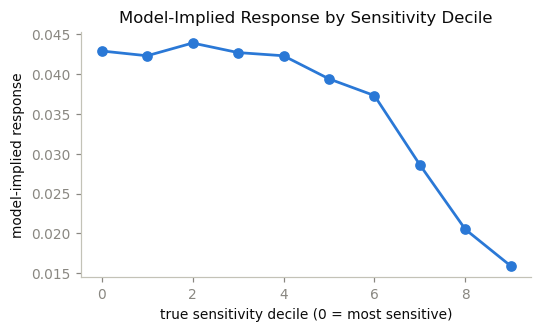

In [12]:
# Check Signal Recovery
lo = score_trips(X[te], trips[te], 0.90)[:, i_np]
hi = score_trips(X[te], trips[te], 1.20)[:, i_np]
implied = (pd.DataFrame({'account_id': trips.loc[te, 'account_id'].to_numpy(),
                         'implied': hi - lo})
           .groupby('account_id')['implied'].mean().reset_index())
chk = implied.merge(ground_truth, on='account_id')

rho = chk['implied'].corr(-chk['price_sensitivity'], method='spearman')
print(f'Spearman, model-implied vs true sensitivity: {rho:+.3f}')
print('Positive = the model ranks sensitivity correctly. Negative = inverted.\n')

by_dec = chk.groupby('sensitivity_decile').agg(accounts=('account_id', 'size'),
                                               mean_implied=('implied', 'mean')).round(4)
print('Model-implied response by TRUE decile (0 = most sensitive)')
display(by_dec.rename_axis(None))

lo_d, hi_d = by_dec['mean_implied'].iloc[0], by_dec['mean_implied'].iloc[-1]
print(f'\nMost sensitive decile responds {lo_d / max(hi_d, 1e-9):.2f}x the least sensitive.')
print('Above 1 is correct. Below 1 means the ranking is inverted.')

fig, ax = plt.subplots(figsize=(5, 3.1))
ax.plot(by_dec.index, by_dec['mean_implied'], marker='o', color=ACCENT, linewidth=1.8)
ax.set_xlabel('true sensitivity decile (0 = most sensitive)')
ax.set_ylabel('model-implied response')
ax.set_title('Model-Implied Response by Sensitivity Decile')
plt.tight_layout()
plt.show()


---
## 10 · Departure: the Rare, Expensive State

**Purpose:** Models account-level departure risk, since no_purchase pools two very different outcomes and departure is the one that costs the whole relationship, not just one trip.

**Design Notes:**

1. Substituting an eSIM costs one trip's pass revenue; leaving costs the whole relationship across every product, and lands outside the roaming P&L entirely
2. Modelled at the account level, where the evidence lives
3. Two limits stated plainly rather than tuned away
  - A few hundred events cannot support a strong model
  - The simulation must carry a range, not a point estimate — the bootstrap sizes that range

**Observations:**

1. 229 of 29,406 accounts departed (0.78%)
2. AUC 0.778 on held-out accounts — real signal, not noise
3. Departure rate rises monotonically across predicted-risk quintiles
4. 95% bootstrap interval: 0.68% to 0.88%, a 1.3x spread


In [13]:
# Model Departure Risk
acct = (trips.groupby('account_id')
        .agg(n_trips=('trip_id', 'size'), avg_days=('days_traveled', 'mean'),
             avg_party=('lines_traveling', 'mean'), avg_price=('price_multiplier', 'mean'),
             max_price=('price_multiplier', 'max'),
             no_purchase_rate=('days_bought', lambda s: (s == 0).mean()),
             avg_ease=('substitute_ease', 'mean'), departed=('account_lost', 'max'),
             last_month=('month', 'max'))
        .reset_index()
        .merge(accounts[['account_id', 'is_business', 'lines_on_account',
                         'tenure_months', 'plan_tier']], on='account_id'))
acct['premium'] = (acct['plan_tier'] == 'premium').astype(int)
print(f'Departures: {int(acct.departed.sum()):,} of {len(acct):,} accounts '
      f'({acct.departed.mean():.3%})')

acols = ['n_trips', 'avg_days', 'avg_party', 'avg_price', 'max_price', 'no_purchase_rate',
         'avg_ease', 'is_business', 'lines_on_account', 'tenure_months', 'premium']
a_tr = (acct['last_month'] <= 19).to_numpy()
a_te = ~a_tr

pos = acct.loc[a_tr, 'departed'].mean()
w = np.where(acct.loc[a_tr, 'departed'] == 1, 0.5 / max(pos, 1e-9), 0.5 / (1 - pos))
dep = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05,
                                     min_samples_leaf=30, random_state=0)
dep.fit(acct.loc[a_tr, acols], acct.loc[a_tr, 'departed'], sample_weight=w)

p_dep = dep.predict_proba(acct.loc[a_te, acols])[:, 1]
actual = acct.loc[a_te, 'departed'].to_numpy()
if actual.sum() >= 10:
    print(f'\nAUC (test accounts): {roc_auc_score(actual, p_dep):.3f}   — 0.5 is no signal')
    q = pd.qcut(p_dep, 5, labels=False, duplicates='drop')
    lift = pd.DataFrame({'q': q, 'actual': actual}).groupby('q')['actual'].agg(['size', 'mean'])
    print('Observed departure rate by predicted-risk quintile')
    display(lift.round(4).rename_axis(None))
else:
    print(f'\nOnly {int(actual.sum())} departures in the test window — cannot validate.')

rng = np.random.default_rng(11)
d = acct['departed'].to_numpy()
boot = [d[rng.integers(0, len(d), len(d))].mean() for _ in range(400)]
DEP_LO, DEP_HI = (float(v) for v in np.percentile(boot, [2.5, 97.5]))
print(f'\nDeparture rate, 95% bootstrap interval: {DEP_LO:.4%} to {DEP_HI:.4%}')
print(f'A {DEP_HI / max(DEP_LO, 1e-12):.1f}x spread — notebook 03 samples across it.')


Departures: 229 of 29,406 accounts (0.779%)



AUC (test accounts): 0.778   — 0.5 is no signal
Observed departure rate by predicted-risk quintile


,size,mean
0,8902,0.0027
1,578,0.0415
2,2319,0.0423



Departure rate, 95% bootstrap interval: 0.6801% to 0.8843%
A 1.3x spread — notebook 03 samples across it.


---
## 11 · Export

**Purpose:** Writes the scored trips, per-account price response, departure risk, and model metadata that notebooks 02-04 load.

**Design Notes:**

1. Parquet preferred (smaller, keeps dtypes); falls back to CSV if pyarrow/fastparquet are not installed
2. response_ratio (§6.2) and the departure bounds (§10) travel with the export, so notebook 03 can bracket the simulation rather than assume the biases away


In [14]:
# Export Results
P_all = score_trips(X, trips)
scored = trips[['trip_id', 'account_id', 'month', 'region', 'is_business',
                'lines_traveling', 'days_traveled', 'price_multiplier', 'y']].copy()
for i, c in enumerate(CLASSES):
    scored[f'p_{c}'] = P_all[:, i]
scored['slice'] = np.select([tr, ca, te], ['train', 'calib', 'test'], default='?')

# Per-account price response — what notebook 04 clusters on
curves = {f'p_np_{m:.2f}': score_trips(X, trips, m)[:, i_np] for m in [0.90, 1.00, 1.10, 1.20]}
resp = pd.DataFrame({'account_id': trips['account_id'].to_numpy(), **curves}) \
         .groupby('account_id').mean().reset_index()
resp['response_span'] = resp['p_np_1.20'] - resp['p_np_0.90']

acct_risk = acct[['account_id']].copy()
acct_risk['p_depart'] = dep.predict_proba(acct[acols])[:, 1]

meta = pd.DataFrame({
    'key': ['day_thresh', 'use_calibration', 'departure_lo', 'departure_hi',
            'response_ratio', 'base_log_loss', 'test_log_loss'],
    'value': [DAY_THRESH, int(USE_CAL), DEP_LO, DEP_HI,
              RESPONSE_RATIO, BASE_LL, LL(y[te], P_te_cal if USE_CAL else P_te)],
})
display(meta.set_index('key').rename_axis(None))

FMT = 'parquet'
try:
    import pyarrow  # noqa: F401
except ImportError:
    try:
        import fastparquet  # noqa: F401
    except ImportError:
        FMT = 'csv'
        print('\npyarrow/fastparquet not found, writing CSV instead.')

paths, rows = [], []
for df, name in [(scored, 'scored_trips'), (resp, 'account_price_response'),
                 (acct_risk, 'account_departure_risk'),
                 (sweep.reset_index(), 'price_sweep'), (meta, 'model_meta')]:
    path = DATA / f'{name}.{FMT}'
    df.to_parquet(path, index=False) if FMT == 'parquet' else df.to_csv(path, index=False)
    paths.append(path.name)
    rows.append(len(df))

display(pd.DataFrame({'rows': rows}, index=paths).rename_axis(None))


,value
day_thresh,0.700000
use_calibration,1.000000
departure_lo,0.006801
departure_hi,0.008843
response_ratio,1.485714
base_log_loss,0.879191
test_log_loss,0.865726


,rows
scored_trips.parquet,94579
account_price_response.parquet,29406
account_departure_risk.parquet,29406
price_sweep.parquet,25
model_meta.parquet,7


---
## What this notebook establishes

| Result | Where | Consequence |
|---|---|---|
| Price effect survives controls | §4 | The response is real, not composition |
| Trees discriminate between accounts | §5 | AUC above 0.5 per class, increases excepted by design |
| Stage-2 coefficients match §4 | §6 | Stage 2 is measuring price, not absorbing something else |
| Net sign correct on every row | §6 | Not just the base coefficient — the effect each trip actually faces |
| Smooth, monotone price curve | §6.1 | Simulation curves will be defensible |
| Response transfer measured | §6.2 | Quantified as a ratio, exported to bracket the simulation |
| Probabilities calibrated | §7–8 | Expected-revenue arithmetic is sound |
| Mechanism recovered, right direction | §9 | Segmentation in 04 targets the right customers |
| Departure rate genuinely uncertain | §10 | Enters the simulation as a bootstrapped range |

### Carry into notebook 03

1. **score_trips(X, df, mult, response_scale)** is the interface. Pass a scalar mult to re-price the book.
2. **Bracket with response_scale.** If §6.2 found the response under-stated, run the simulation at 1.0 and at the measured ratio and report both. An unbracketed answer overstates the safety of a price rise.
3. **Draw the macro shock once per iteration**, applied to every account. Independent draws understate the spread and report confidence the analysis has not earned.
4. **Sample the departure rate** between departure_lo and departure_hi.
5. **Expect the +20% cap to bind.** The panel is net inelastic across the range, so revenue is still climbing at the ceiling. Say plainly that the constraint chose +20%, not the model.

### Next

02_magnitude_model.ipynb — conditional day and line counts for reduces and increases, fitted only on trips in those states, so expected revenue has a size to multiply by and not just a direction.